In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#Cargamos load_diabetes
from sklearn.datasets import load_diabetes
#Cargamos train_test_split
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


          age       sex       bmi        bp        s1        s2        s3  \
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
..        ...       ...       ...       ...       ...       ...       ...   
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   

           s4        s5        s6  
0   -0.002592  0.019907 -0.017646  
1  

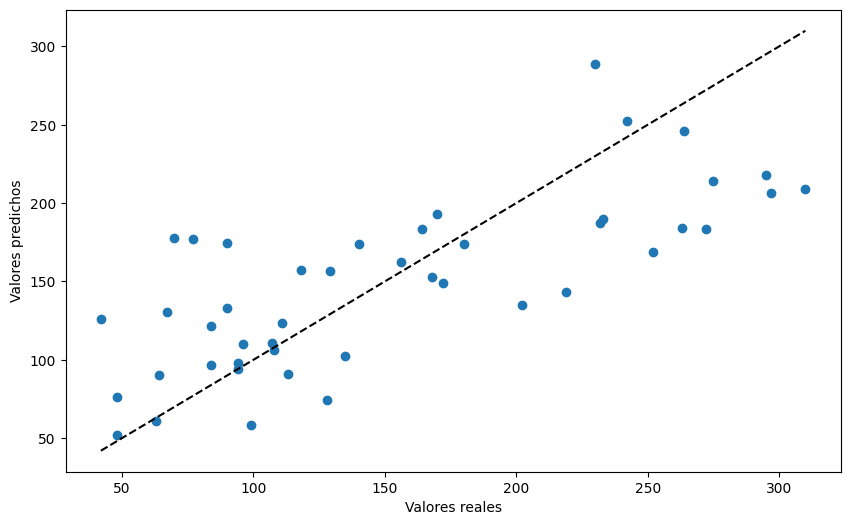

In [10]:
#pipeline
from sklearn.pipeline import Pipeline
diabetes = load_diabetes()
#print(diabetes)
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target)
print(X)
print(y)
#Dividir datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LinearRegression())
])

#Validacion cruzada (cross validation k = 5)
cv_result = cross_validate(estimator=pipeline, X=X_train, y=y_train,cv=3, scoring = {
    'R2' : 'r2',
    'MAE' : 'neg_mean_absolute_error',
    'RMSE' : 'neg_root_mean_squared_error'
},
return_train_score = True
)
resultados_cv = pd.DataFrame({
    'Fold': np.arange(1,4),
    'R2': cv_result['test_R2'],
    'MAE': -cv_result['test_MAE'],
    'RMSE': -cv_result['test_RMSE']
})
print(f"Resultados por Fold: {resultados_cv}")
#Promedios de la validacion cruzada
r2_prom = cv_result['test_R2'].mean()
mae_prom = cv_result['test_MAE'].mean()
rmse_prom = cv_result['test_RMSE'].mean()

#Entrenamiento
pipeline.fit(X_train, y_train)
#prediccion
y_pred = pipeline.predict(X_test)
#Evaluacion del modelo
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'MAE {mae}, RMSE {rmse} y r2 {r2}')

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.show()


Text(0, 0.5, 'Residuos')

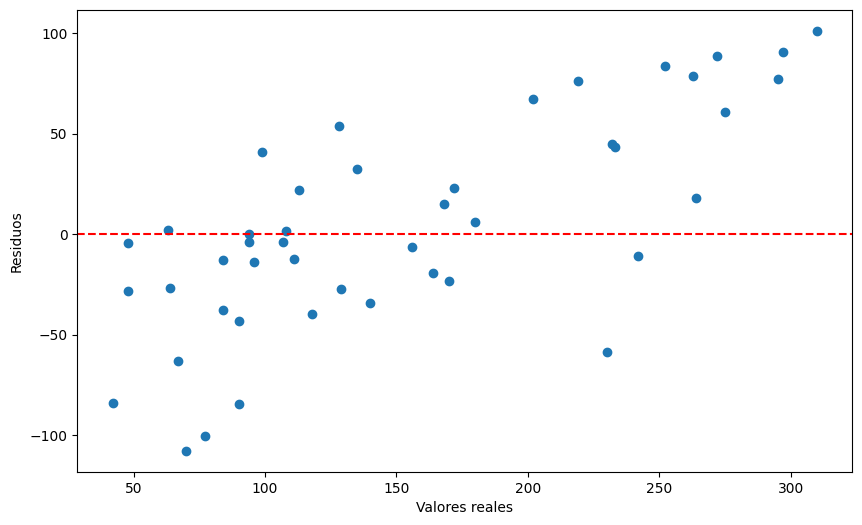

In [11]:
#residuos
residuos = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores reales')
plt.ylabel('Residuos')

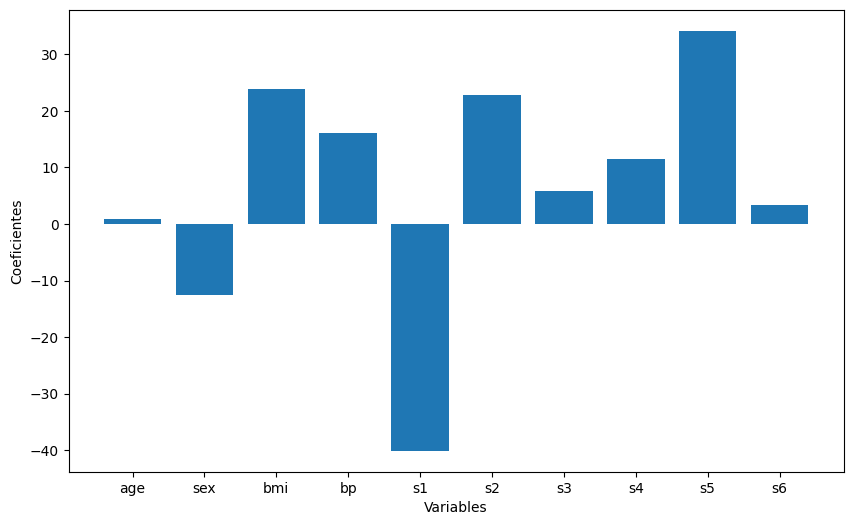

In [12]:
#Importancia estadistica (p-values)
coeficientes = pd.DataFrame({
    "Variable":X.columns,
    "Coeficientes":pipeline.named_steps["model"].coef_
    })
coeficientes["Abs"]=(
    coeficientes["Coeficientes"].mean()
)
coeficientes = coeficientes.sort_values(by="Abs", ascending=False)
coeficientes.head(10)

#Graficar coeficientes
plt.figure(figsize=(10, 6))
plt.bar(coeficientes["Variable"], coeficientes["Coeficientes"])
plt.xlabel("Variables")
plt.ylabel("Coeficientes")
plt.show()